In [25]:
# ============================ HTF VAR WORKFLOW ============================
# HTF MODEL (4H,D,W,M)
# CELL 1: IMPORTS
import datetime, warnings, contextlib, io, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from arch.unitroot import ADF
except ImportError:
    !pip install arch -q
    from arch.unitroot import ADF

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

In [29]:
# CELL 2: CONFIG + DATA LOADING
DATA_SOURCE = "yfinance"                  # 'csv' or 'yfinance'
TIMEFRAME = "D"                      # '4H' | 'D' | 'W' | 'M'
TRAINING_DATA_MODE = "recent_bars"   # 'recent_bars' | 'full' | 'custom_range'
START_DATE = "2020-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")

# HTF -> use MORE history (few bars per year). Values are in BARS.
TRAIN_BARS     = {"4H": 3000, "D": 2500, "W": 520, "M": 240}
MAX_LAGS       = {"4H": 12,   "D": 12,   "W": 8,   "M": 6}
FORECAST_STEPS = {"4H": 30,   "D": 30,   "W": 12,  "M": 6}
LAG_CRITERION = "aic"                # 'aic' | 'bic' | 'hqic' | 'fpe'

INSTRUMENTS = [
    {"alias": "REL", "yf_ticker": "RELIANCE.NS", "csv_file_path": r"D:\data\nas100_usd_1h.csv", "csv_column": "Close"},
    {"alias": "ICICI", "yf_ticker": "ICICIBANK.NS", "csv_file_path": r"D:\data\spx500_usd_1h.csv", "csv_column": "Close"},
    # add a 3rd instrument here if you want (like the application: 3 series)
]

us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
BAR      = {"4H": pd.offsets.Hour(4), "D": pd.offsets.Day(1), "W": "W-FRI", "M": pd.offsets.MonthEnd()}
BAR_TD   = {"4H": pd.Timedelta("4h"), "D": pd.Timedelta("1D"), "W": pd.Timedelta("7D"), "M": pd.Timedelta("28D")}
NEXT_BAR = {"4H": pd.offsets.Hour(4), "D": us_bd, "W": pd.offsets.Week(weekday=4), "M": pd.offsets.MonthEnd()}

DATE_NAMES  = ["date", "datetime", "time", "timestamp", "formatted date"]
PRICE_NAMES = ["close", "c", "price", "last"]


def read_csv_series(inst):
    df = pd.read_csv(inst["csv_file_path"])
    df.columns = df.columns.str.strip()
    date_col = next((c for c in df.columns if c.lower() in DATE_NAMES), None)
    if date_col is None:
        raise KeyError(f"No date column in {inst['csv_file_path']}: {list(df.columns)}")
    want = inst["csv_column"]
    price_col = want if want in df.columns else next(
        (c for c in df.columns if c.lower() in [want.lower(), *PRICE_NAMES]), None)
    if price_col is None:
        raise KeyError(f"No price column in {inst['csv_file_path']}: {list(df.columns)}")
    idx = pd.to_datetime(df[date_col], format="mixed")
    if getattr(idx.dt, "tz", None) is not None:
        idx = idx.dt.tz_localize(None)
    s = pd.Series(df[price_col].values, index=idx, name=inst["alias"]).sort_index()
    s = s[~s.index.duplicated(keep="last")]
    if s.index.to_series().diff().median() > BAR_TD[TIMEFRAME] * 1.5:
        raise ValueError(f"{inst['alias']}: source data is coarser than {TIMEFRAME}")
    return s


def load_yf():
    import yfinance as yf
    tk = [i["yf_ticker"] for i in INSTRUMENTS]
    if TIMEFRAME == "4H":   # yfinance has no 4H -> pull 1h and resample
        raw = yf.download(tk, period="730d", interval="1h", progress=False)["Close"]
    else:
        raw = yf.download(tk, start=START_DATE, end=END_DATE, interval="1d", progress=False)["Close"]
    if isinstance(raw, pd.Series):
        raw = raw.to_frame(tk[0])
    raw = raw.rename(columns={i["yf_ticker"]: i["alias"] for i in INSTRUMENTS})
    raw = raw[[i["alias"] for i in INSTRUMENTS]]
    if raw.index.tz is not None:
        raw.index = raw.index.tz_localize(None)
    return raw


def load_prices():
    if DATA_SOURCE == "yfinance":
        df = load_yf()
    else:
        df = pd.concat([read_csv_series(i) for i in INSTRUMENTS], axis=1)
    # resample to the target HTF bar (last close of each bar)
    df = df.sort_index().resample(BAR[TIMEFRAME]).last().dropna()
    total = len(df)
    if TRAINING_DATA_MODE == "recent_bars" and TRAIN_BARS[TIMEFRAME]:
        df = df.tail(TRAIN_BARS[TIMEFRAME])
    elif TRAINING_DATA_MODE == "custom_range":
        df = df.loc[START_DATE:END_DATE]
    print(f"[{TIMEFRAME}] using {len(df)} bars of {total} | {df.index[0]} -> {df.index[-1]}")
    if len(df) < 60:
        print("WARNING: very few bars - VAR estimates will be unreliable.")
    return df


data = load_prices()
data.tail()

[D] using 1674 bars of 1674 | 2020-01-01 00:00:00 -> 2026-09-28 00:00:00


Ticker,REL,ICICI
Date,,
2026-09-22,1240.400024,1339.599976
2026-09-23,1248.000000,1340.000000
2026-09-24,1219.199951,1334.500000
2026-09-25,1226.000000,1326.800049
2026-09-28,1197.599976,1302.000000


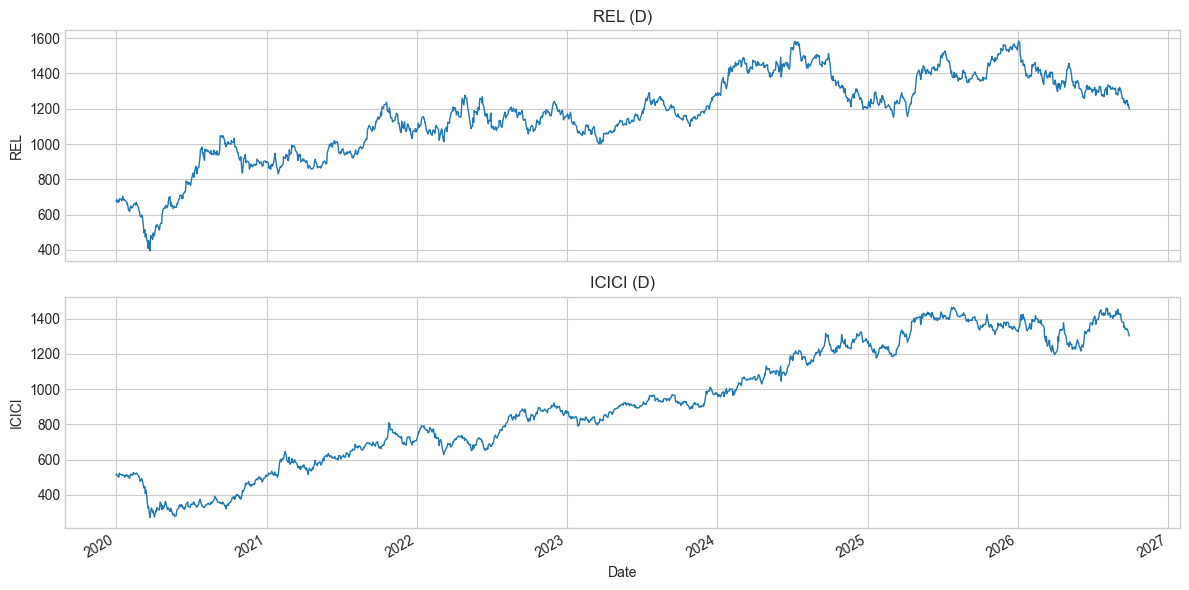

In [30]:
# CELL 3: FIGURE 1 - TIME PLOTS (LEVELS)
n = len(data.columns)
fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), data.columns):
    data[col].plot(ax=ax, linewidth=1, xlabel="Date", ylabel=col, title=f"{col} ({TIMEFRAME})")
fig.tight_layout()
plt.show()

In [31]:
# CELL 4: FIGURE 2 - ADF TEST ON LEVELS (5% level, trend='n', BIC)
def adf_table(df):
    rows = {}
    for c in df.columns:
        a = ADF(df[c].dropna(), trend="n", method="bic")
        rows[c] = {"ADF Test Statistic": a.stat, "5% Critical Value": a.critical_values["5%"],
                   "p-value": a.pvalue, "Stationary": a.stat < a.critical_values["5%"]}
    return pd.DataFrame(rows).T.round(4)

print("--- ADF on LEVELS (Stationary=False -> unit root) ---")
adf_table(data)

--- ADF on LEVELS (Stationary=False -> unit root) ---


,ADF Test Statistic,5% Critical Value,p-value,Stationary
REL,0.268468,-1.941162,0.766223,False
ICICI,1.112753,-1.941162,0.930517,False


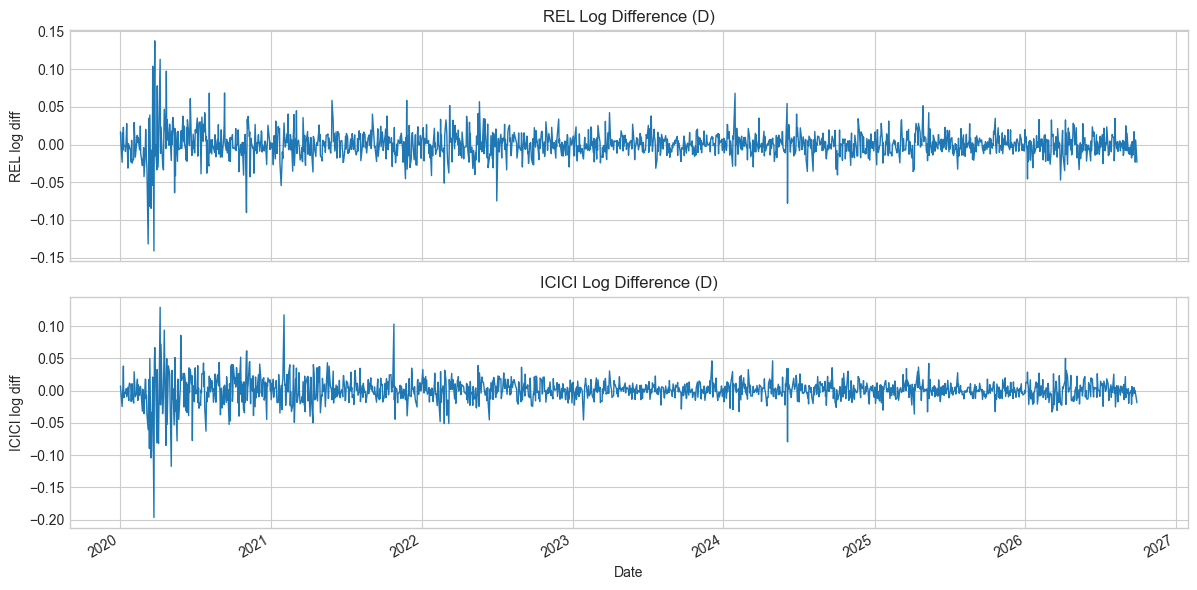

--- ADF on LOG-DIFFERENCED data ---


,ADF Test Statistic,5% Critical Value,p-value,Stationary
REL,-42.985589,-1.941162,0.0,True
ICICI,-16.378317,-1.941162,0.0,True


In [32]:
# CELL 5: FIGURES 3 & 4 - LOG DIFFERENCE + ADF
diff_data = np.log(data).diff().dropna()      # same as application: log difference

fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), diff_data.columns):
    diff_data[col].plot(ax=ax, linewidth=1, xlabel="Date", ylabel=f"{col} log diff",
                        title=f"{col} Log Difference ({TIMEFRAME})")
fig.tight_layout()
plt.show()

print("--- ADF on LOG-DIFFERENCED data ---")
adf_table(diff_data)

In [33]:
# CELL 6: GRANGER CAUSALITY (all ordered pairs)
def granger(df, cause, effect, maxlag=4):
    with contextlib.redirect_stdout(io.StringIO()):
        r = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return pd.DataFrame([{
        "Lag": l,
        "F-Stat": round(r[l][0]["ssr_ftest"][0], 4),
        "p-value": round(r[l][0]["ssr_ftest"][1], 4),
        "Significant (p<0.05)": r[l][0]["ssr_ftest"][1] < 0.05} for l in range(1, maxlag + 1)])

for a, b in itertools.permutations(diff_data.columns, 2):
    print(f"\n--- Does {a} Granger-cause {b}? ---")
    print(granger(diff_data, cause=a, effect=b).to_string(index=False))


--- Does REL Granger-cause ICICI? ---
 Lag  F-Stat  p-value  Significant (p<0.05)
   1 11.6894   0.0006                  True
   2  7.5774   0.0005                  True
   3  5.4389   0.0010                  True
   4  4.2549   0.0020                  True

--- Does ICICI Granger-cause REL? ---
 Lag  F-Stat  p-value  Significant (p<0.05)
   1  0.0054   0.9417                 False
   2  0.1883   0.8284                 False
   3  0.6406   0.5889                 False
   4  0.6960   0.5947                 False


In [34]:
# CELL 7: FIGURE 5 - LAG SELECTION
model = VAR(diff_data)
k = diff_data.shape[1]
max_l = min(MAX_LAGS[TIMEFRAME], (len(diff_data) - 1) // (k + 1))
sel = model.select_order(maxlags=max_l, trend="c")
print(sel.summary())

optimal_lag = max(1, sel.selected_orders[LAG_CRITERION])
print(f"\nSelected lag ({LAG_CRITERION.upper()}): {optimal_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -16.29     -16.29*   8.381e-08     -16.29*
1       -16.30      -16.28   8.352e-08      -16.29
2       -16.30      -16.26   8.371e-08      -16.28
3       -16.30      -16.25   8.371e-08      -16.28
4       -16.30      -16.24   8.377e-08      -16.27
5       -16.31      -16.24   8.260e-08      -16.28
6       -16.32      -16.23   8.212e-08      -16.28
7       -16.32      -16.22   8.206e-08      -16.28
8       -16.31      -16.20   8.220e-08      -16.27
9       -16.31      -16.19   8.241e-08      -16.27
10      -16.31      -16.18   8.229e-08      -16.26
11     -16.32*      -16.17  8.184e-08*      -16.26
12      -16.32      -16.15   8.196e-08      -16.26
--------------------------------------------------

Selected lag (AIC): 11


In [35]:
# CELL 8: FIGURE 6 - FIT VAR(p) WITH INTERCEPT
var_results = model.fit(optimal_lag, trend="c", method="ols")
print(var_results.summary())
lag_order = var_results.k_ar
print("Lag order:", lag_order)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 29, Sep, 2026
Time:                     12:17:25
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -16.1672
Nobs:                     1662.00    HQIC:                  -16.2616
Log likelihood:           8888.99    FPE:                8.19520e-08
AIC:                     -16.3171    Det(Omega_mle):     7.97300e-08
--------------------------------------------------------------------
Results for equation REL
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.000362         0.000425            0.850           0.395
L1.REL           -0.039155         0.027002           -1.450           0.147
L1.ICICI          0.009585         0.025953            0.369           0.712
L

Eigenvalues of VAR(1) rep
0.7980071208781399
0.7929116660908626
0.7929116660908626
0.8063013843863074
0.8063013843863074
0.7987350475924995
0.7987350475924995
0.8215375148773802
0.8215375148773802
0.8137256703684482
0.8137256703684482
0.7209405456730273
0.7209405456730273
0.8027118688300763
0.8027118688300763
0.8679443408487064
0.8679443408487064
0.7309273035879084
0.7309273035879084
0.5449321952539141
0.6954582170994372
0.7722091432940564

Stable / ergodic: True
Residual whiteness p-value: 0.147


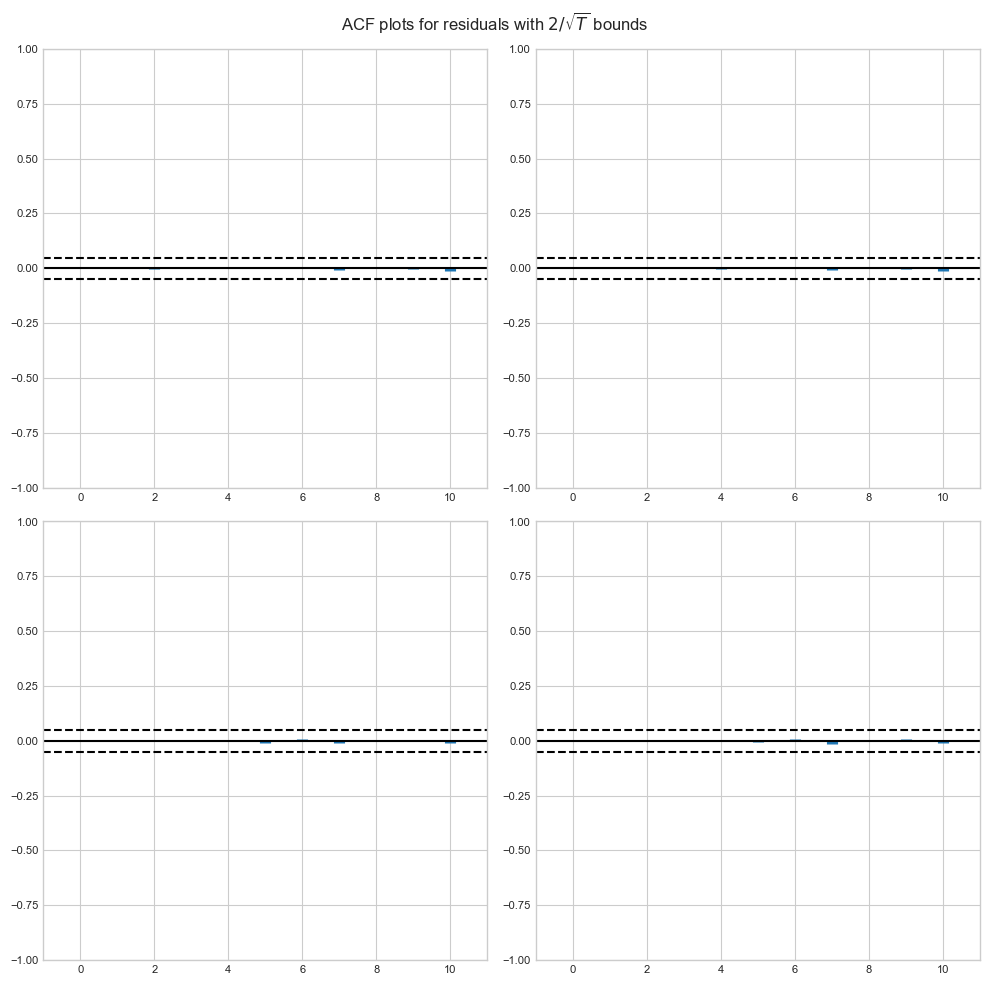

In [36]:
# CELL 9: DIAGNOSTICS - STABILITY + RESIDUAL WHITENESS
is_stable = var_results.is_stable(verbose=True)
print(f"\nStable / ergodic: {is_stable}")

wh = var_results.test_whiteness(nlags=var_results.k_ar + 1)
print(f"Residual whiteness p-value: {round(wh.pvalue, 4)}")

var_results.plot_acorr()
plt.tight_layout()
plt.show()

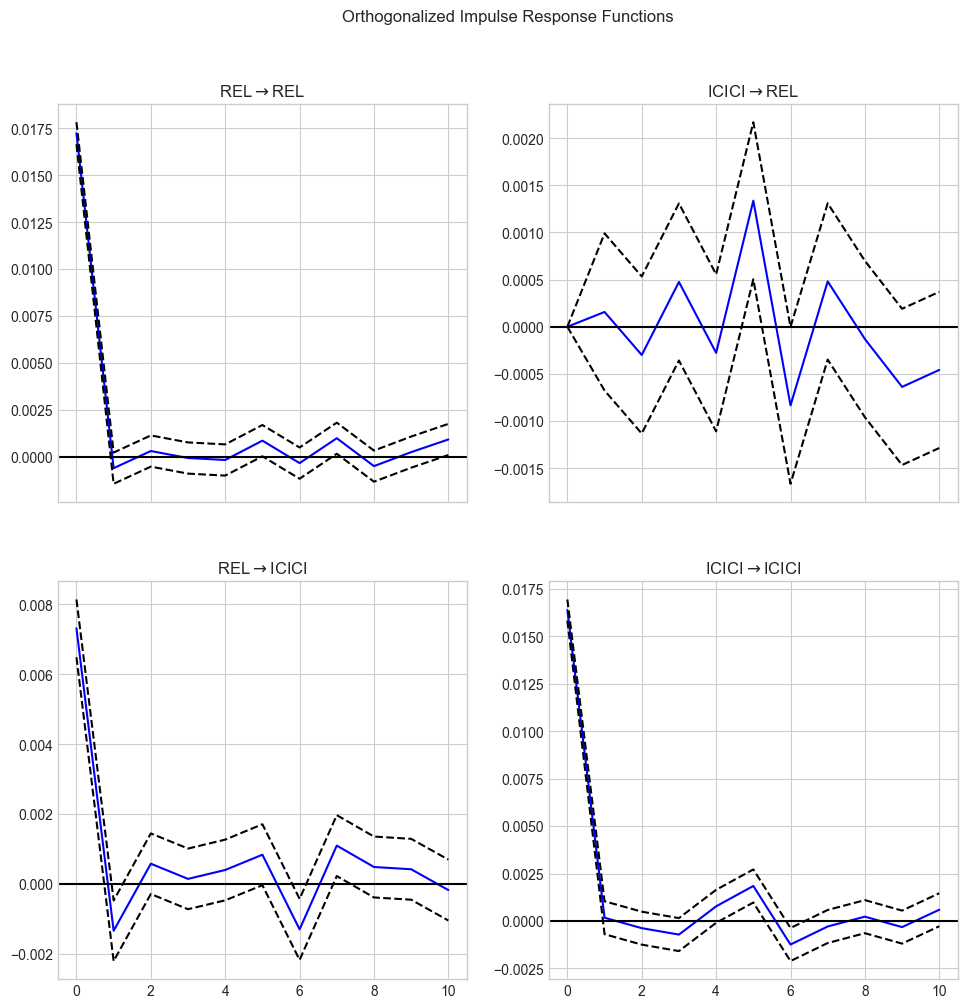

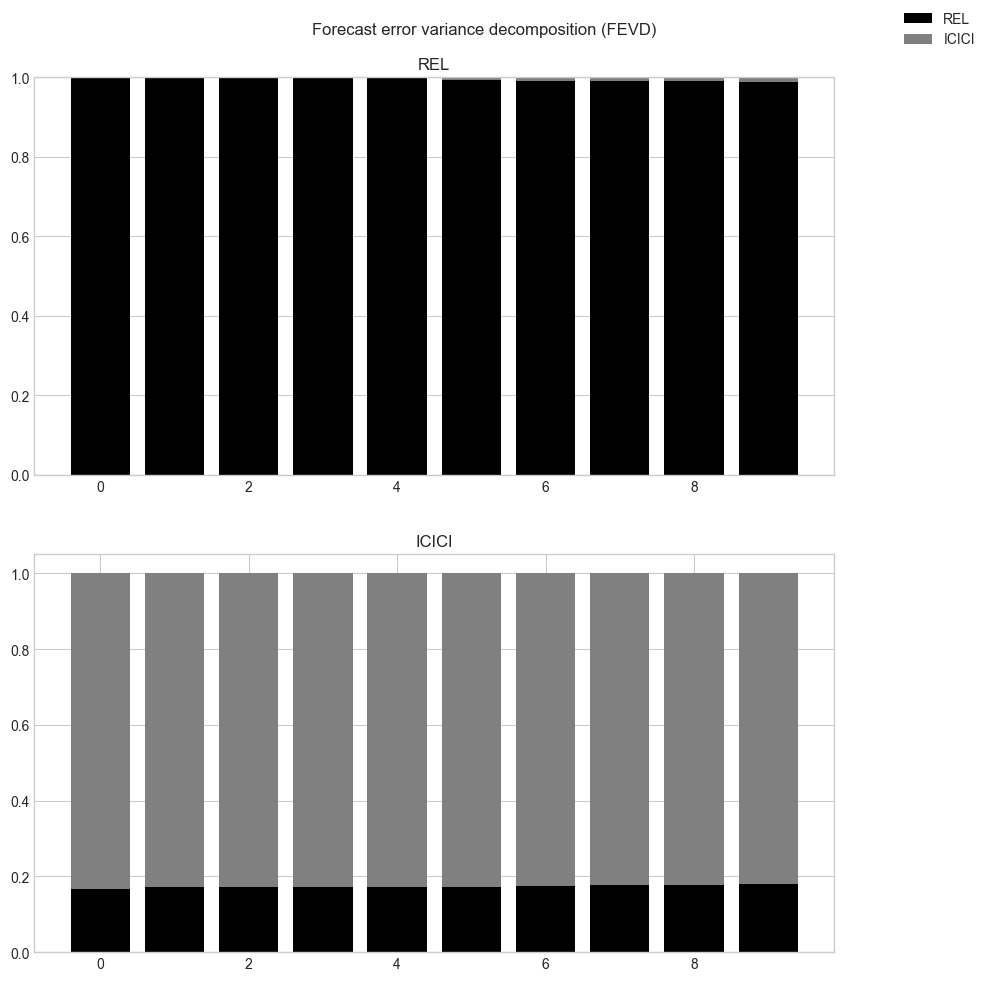

In [37]:
# CELL 10: IRF + FEVD
irf = var_results.irf(periods=10)
irf.plot(orth=True)
plt.suptitle("Orthogonalized Impulse Response Functions", y=1.02)
plt.show()

var_results.fevd(periods=10).plot()
plt.show()

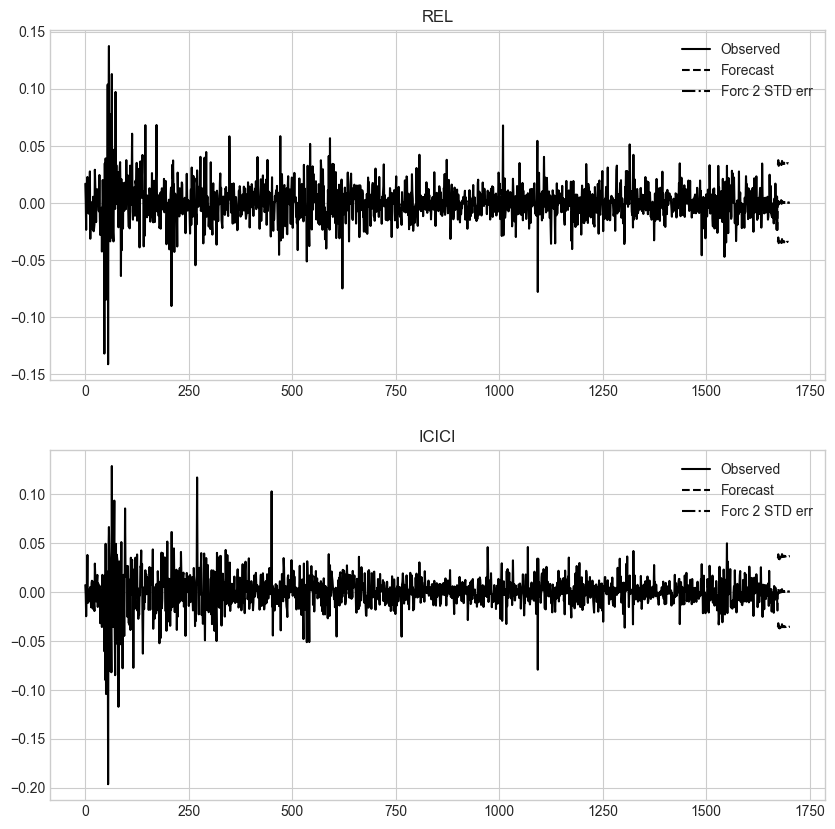

In [38]:
# CELL 11: FIGURE 7 - FORECAST OF DIFFERENCED SERIES
steps = FORECAST_STEPS[TIMEFRAME]
var_results.plot_forecast(steps=steps, alpha=0.05, plot_stderr=True)
plt.show()

            RELForecast  ICICIForecast
2026-09-29  1197.477532    1301.646715
2026-09-30  1201.890767    1306.064626
2026-10-01  1200.330489    1304.443503
2026-10-02  1201.258619    1305.552517
2026-10-05  1200.688874    1303.190118
2026-10-06  1201.420031    1305.156247
2026-10-07  1200.869030    1304.636637
2026-10-08  1200.283012    1304.025858
2026-10-09  1203.299907    1306.983386
2026-10-13  1202.420245    1306.972773


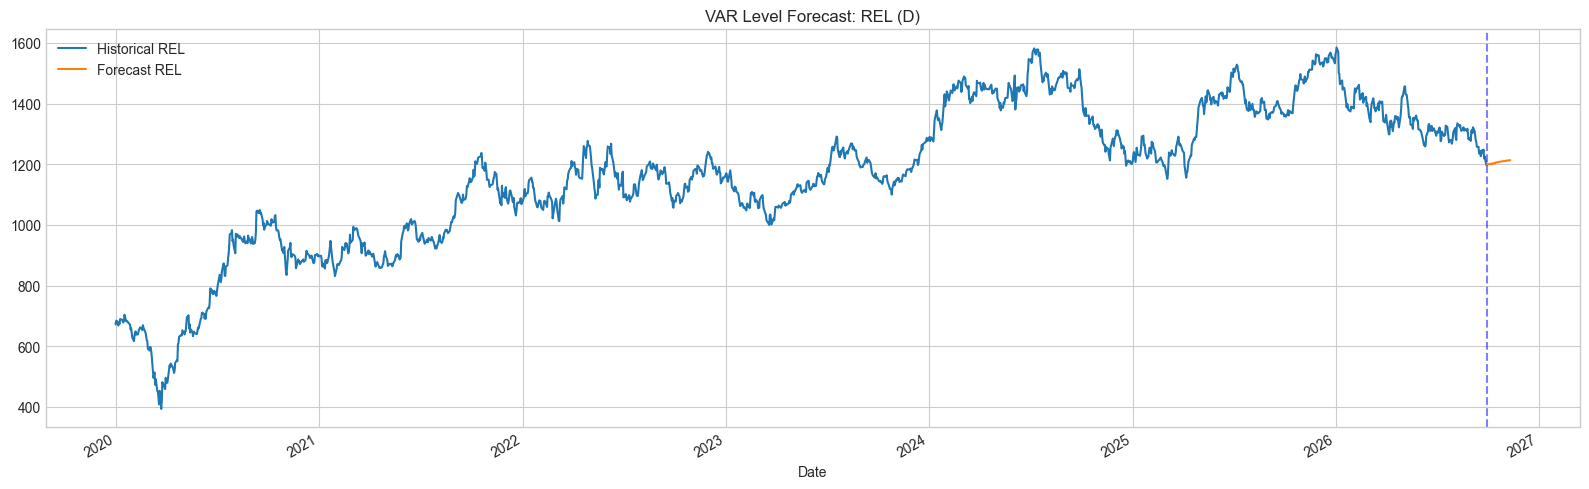

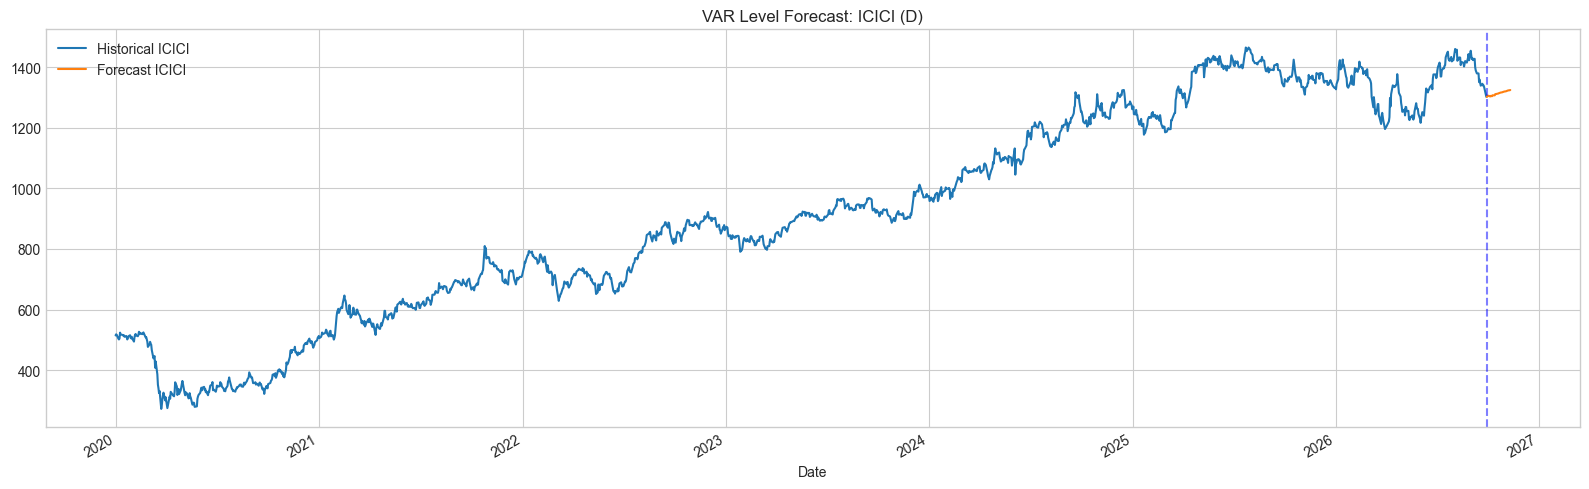

In [39]:
# CELL 12: FIGURE 8 - FORECAST OF LEVELS (log-diff -> cumsum -> exp)
pred = var_results.forecast(y=diff_data.values[-lag_order:], steps=steps)

idx = pd.date_range(start=data.index[-1] + NEXT_BAR[TIMEFRAME], periods=steps, freq=NEXT_BAR[TIMEFRAME])
df_forecast = pd.DataFrame(pred, index=idx, columns=[f"{c}_logret" for c in data.columns])

for col in data.columns:
    last_log = np.log(data[col].iloc[-1])
    df_forecast[f"{col}Forecast"] = np.exp(last_log + df_forecast[f"{col}_logret"].cumsum())

print(df_forecast[[f"{c}Forecast" for c in data.columns]].head(10))

for col in data.columns:
    plt.figure(figsize=(16, 5))
    data[col].plot(legend=True, label=f"Historical {col}")
    df_forecast[f"{col}Forecast"].plot(legend=True, label=f"Forecast {col}")
    plt.axvline(x=idx[0], color="b", alpha=0.5, linestyle="--")
    plt.title(f"VAR Level Forecast: {col} ({TIMEFRAME})")
    plt.legend()
    plt.tight_layout()
    plt.show()